In [9]:
import os
import pandas as pd
import pm4py  # version 2.7.4
from pprint import pprint  # pretty printing
from pm4py.algo.discovery.alpha import algorithm as alpha_miner
from pm4py.algo.discovery.heuristics import algorithm as heuristics_miner
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.algo.evaluation import algorithm as evaluation
from pm4py.objects.conversion.log import converter as stream_converter
from pm4py.objects.log.importer.xes import importer as xes_import
from pm4py.visualization.petri_net import visualizer as pn_visualizer
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay
import pulp

In [10]:
## --- Recall and Comprehensibility ---


def compute_recall(eval_result):
    precision = eval_result["precision"]
    fscore = eval_result["fscore"]

    # evitar divisões por zero
    if precision == 0 or (2 * precision - fscore) == 0:
        return 0.0

    recall = (fscore * precision) / (2 * precision - fscore)
    return recall

def compute_comprehensibility(net):
    num_places = len(net.places)
    num_transitions = len(net.transitions)

    total_elements = num_places + num_transitions

    if total_elements == 0:
        return 0.0

    # quanto menor a estrutura, maior o score
    return 1 / total_elements



In [11]:
import pandas as pd
import pm4py
from graphviz import Source
from typing import List, Dict, Tuple, Set, Optional


In [12]:
# Load CSV
df = pd.read_csv("caseid_day_HypoHyper/processed/event_log.csv")


df = df.rename(columns={
    "case_id": "case:concept:name",
    "event_type": "concept:name",
    "timestamp": "time:timestamp",
    "value": "glucose_value"
})


df["case:concept:name"] = df["case:concept:name"].astype(str)
df["concept:name"] = df["concept:name"].astype(str)
df["time:timestamp"] = pd.to_datetime(df["time:timestamp"])


df = df.sort_values(["case:concept:name", "time:timestamp"])

df.head()


,case:concept:name,concept:name,time:timestamp,glucose_value
0,2023-10-01,HyperglycemiaStart,2023-10-01 00:09:00,8.0
1,2023-10-01,HyperglycemiaEnd,2023-10-01 09:04:00,7.8
2,2023-10-01,HyperglycemiaStart,2023-10-01 11:34:00,7.9
3,2023-10-01,SleepTime,2023-10-01 20:51:00,33840.0
4,2023-10-02,HyperglycemiaStart,2023-10-02 00:04:00,21.6


In [13]:

event_log = pm4py.convert_to_event_log(df)

print(f"Traces: {len(event_log)}")
print(f"Eventos: {len(df)}")


EL = []

for trace in event_log:
    trace_activities = [event["concept:name"] for event in trace]
    EL.append(trace_activities)


EL[:3]


Traces: 110
Eventos: 3718


[['HyperglycemiaStart', 'HyperglycemiaEnd', 'HyperglycemiaStart', 'SleepTime'],
 ['HyperglycemiaStart',
  'HyperglycemiaEnd',
  'HyperglycemiaStart',
  'HyperglycemiaEnd',
  'HyperglycemiaStart',
  'SleepTime',
  'HyperglycemiaEnd'],
 ['HyperglycemiaStart',
  'HyperglycemiaEnd',
  'HyperglycemiaStart',
  'HyperglycemiaEnd',
  'HyperglycemiaStart',
  'HyperglycemiaEnd',
  'HyperglycemiaStart',
  'SleepTime',
  'HyperglycemiaEnd',
  'HyperglycemiaStart']]

In [14]:
class TaskMiner:
    def __init__(
        self,
        event_log: List[List[str]],
        collapse_repeats: bool = True,
        count_collapsed: bool = True,
        backward_context: int = 1,
        forward_context: int = 1,
        tDUP: float = 0.90,
    ):
        self.event_log = event_log
        self.collapse_repeats = collapse_repeats
        self.count_collapsed = count_collapsed
        self.backward_context = backward_context
        self.forward_context = forward_context
        self.tDUP = tDUP

        self._reset()

    def _reset(self) -> None:
        self.MAPPING: Dict[Tuple[str, Tuple[str, ...], Tuple[str, ...]], int] = {}
        self.TC: Set[int] = set()
        self.counts: Dict[Tuple[str, Tuple[str, ...], Tuple[str, ...]], int] = {}
        self.next_task = 0
        self.idx_to_task: Dict[int, str] = {}
        self.most_started = -1
        self.most_ended = -1

    def _fragment(
        self, sigma: List[str], i: int
    ) -> Tuple[str, Tuple[str, ...], Tuple[str, ...]]:
        b = tuple(sigma[max(0, i - self.backward_context) : i])
        f = tuple(sigma[i + 1 : min(len(sigma), i + 1 + self.forward_context)])
        return (sigma[i], b, f)

    def _collapse_fragments(self) -> None:
        done = False
        while not done:
            done = True
            for frag1 in self.MAPPING:
                for frag2 in self.MAPPING:
                    if (
                        self.MAPPING[frag1] == self.MAPPING[frag2]
                        or frag1[0] != frag2[0]
                    ):
                        continue
                    if frag1[1] == frag2[1] or frag1[2] == frag2[2]:
                        done = False
                        for frag3 in self.MAPPING:
                            if self.MAPPING[frag3] == self.MAPPING[frag2]:
                                self.MAPPING[frag3] = self.MAPPING[frag1]

    def _filter_tDUP(self) -> None:
        task_log = set(x for y in self.event_log for x in y)
        for act in task_log:
            total_freq = sum(
                self.counts[fragment] for fragment in self.MAPPING if fragment[0] == act
            )
            fragments = [fragment for fragment in self.MAPPING if fragment[0] == act]
            if not fragments:
                continue
            max_fragment = max(fragments, key=lambda x: self.counts[x] / total_freq)
            highest_task = self.MAPPING[max_fragment]
            for fragment in fragments:
                freq = self.counts[fragment] / total_freq
                if freq < self.tDUP:
                    for fragment2 in self.MAPPING:
                        if self.MAPPING[fragment2] == self.MAPPING[fragment]:
                            self.MAPPING[fragment2] = highest_task

    def mine(self) -> None:
        self._reset()

        # Map fragments and collapse duplicates
        for sigma in self.event_log:
            prev = None
            prev_task_idx = -1
            for i in range(len(sigma)):
                fragment = self._fragment(sigma, i)
                if self.collapse_repeats and prev == sigma[i]:
                    self.MAPPING[fragment] = prev_task_idx
                    if self.count_collapsed:
                        self.counts[fragment] = self.counts.get(fragment, 0) + 1
                else:
                    if fragment not in self.MAPPING:
                        self.MAPPING[fragment] = self.next_task
                        self.counts[fragment] = 0
                        self.next_task += 1
                    self.counts[fragment] += 1
                    prev_task_idx = self.MAPPING[fragment]
                prev = sigma[i]

        # Collapse mappings
        self._collapse_fragments()

        # Filter by tDUP
        self._filter_tDUP()
        self.TC = set(self.MAPPING.values())
        self.idx_to_task = {v: k[0] for k, v in self.MAPPING.items()}

        # Most started and ended
        self.most_started = max(
            self.TC,
            key=lambda x: sum(self.mu(sigma, 0) == x for sigma in self.event_log),
        )
        self.most_ended = max(
            self.TC,
            key=lambda x: sum(
                self.mu(sigma, len(sigma) - 1) == x for sigma in self.event_log
            ),
        )

    def mu(self, sigma: List[str], i: int) -> int:
        return self.MAPPING[self._fragment(sigma, i)]

    def tau(self, idx: int) -> Optional[str]:
        return self.idx_to_task.get(idx)


class DependencyGraph:
    def __init__(
        self,
        tm: "TaskMiner",
        tD: float = 0.5,
        tL1L: float = 0.5,
        tL2L: float = 0.5,
        tLD: float = 0.9,
        prevent_l2l_with_l1l: bool = True,
        prefer_and_to_l2l: bool = True,
        all_connected: bool = True,
        long_dependencies: bool = False,
    ):
        self.tm = tm
        self.TC = tm.TC
        self.tD = tD
        self.tL1L = tL1L
        self.tL2L = tL2L
        self.tLD = tLD
        self.prevent_l2l_with_l1l = prevent_l2l_with_l1l
        self.prefer_and_to_l2l = prefer_and_to_l2l
        self.all_connected = all_connected
        self.long_dependencies = long_dependencies

        self._reset()

    def _reset(self) -> None:
        self.measureA = {a: 0 for a in self.TC}
        self.measureAB = {(a, b): 0 for a in self.TC for b in self.TC}
        self.measureABA = {(a, b): 0 for a in self.TC for b in self.TC}
        self.measureAXB = {(a, b): 0 for a in self.TC for b in self.TC}

        self.DG: Set[Tuple[int, int]] = set()
        self.LONGD: Set[Tuple[int, int]] = set()

    def dep_measure(self, a: int, b: int) -> float:
        ab = self.measureAB[(a, b)]
        ba = self.measureAB[(b, a)]
        return ab / (ab + ba + 1)

    def l1l_measure(self, a: int) -> float:
        return self.measureAB[(a, a)] / (self.measureAB[(a, a)] + 1)

    def l2l_measure(self, a: int, b: int) -> float:
        aba = self.measureABA[(a, b)]
        bab = self.measureABA[(b, a)]
        return (aba + bab) / (aba + bab + 1)

    def ldi_measure(self, a: int, b: int) -> float:
        axb = self.measureAXB[(a, b)]
        aa = self.measureA[a]
        bb = self.measureA[b]
        return (2.0 * axb) / (aa + bb + 1) - (2.0 * abs(aa - bb)) / (aa + bb + 1)

    def pat_measure(self, t: int, x: float) -> float:
        return x / self.measureA[t]

    def path_exists_without_visiting(self, start: int, end: int, visiting: int) -> bool:
        todo = set([start])
        visited = set([start])
        while len(todo):
            t = todo.pop()
            if t == visiting:
                continue
            visited |= {t}
            outputs = set([ab[1] for ab in self.DG if ab[0] == t])
            outputs -= visited
            todo |= outputs
            if end in visited:
                return True
        return False

    def get_unconnected_tasks(self, from_start: bool = True) -> Set[int]:
        start = self.tm.most_started if from_start else self.tm.most_ended
        todo = {start}
        visited = {start}
        while todo:
            t = todo.pop()
            outputs = {b for a, b in self.DG if a == t}
            inputs = {a for a, b in self.DG if b == t}
            next_tasks = outputs if from_start else inputs
            next_tasks -= visited
            visited |= next_tasks
            todo |= next_tasks
        return set(self.TC) - visited

    def _extract_relations(self, event_log: List[List[str]]) -> None:
        for sigma in event_log:
            for i in range(len(sigma)):
                a = self.tm.mu(sigma, i)
                self.measureA[a] += 1
            for i in range(len(sigma) - 1):
                a, b = self.tm.mu(sigma, i), self.tm.mu(sigma, i + 1)
                self.measureAB[(a, b)] += 1
            for i in range(len(sigma) - 2):
                a, b, c = (
                    self.tm.mu(sigma, i),
                    self.tm.mu(sigma, i + 1),
                    self.tm.mu(sigma, i + 2),
                )
                if a == c:
                    self.measureABA[(a, b)] += 1
            for i in range(len(sigma)):
                for j in range(i + 1, len(sigma)):
                    skip = False
                    for k in range(i + 1, j):
                        if self.tm.mu(sigma, j) == self.tm.mu(sigma, k):
                            skip = True
                            break
                    if not skip:
                        a, b = self.tm.mu(sigma, i), self.tm.mu(sigma, j)
                        self.measureAXB[(a, b)] += 1
                    if self.tm.mu(sigma, i) == self.tm.mu(sigma, j):
                        break

    def _build_basic_graph(self) -> None:
        # Basic dependencies and L1L
        for a in self.TC:
            if self.l1l_measure(a) >= self.tL1L:
                self.DG.add((a, a))
            for b in self.TC:
                if self.dep_measure(a, b) >= self.tD:
                    self.DG.add((a, b))

        # Add L2L
        for a in self.TC:
            for b in self.TC:
                if a == b:
                    continue
                if (
                    self.prevent_l2l_with_l1l
                    and (a, a) in self.DG
                    and (b, b) in self.DG
                ):
                    continue
                if self.l2l_measure(a, b) >= self.tL2L:
                    self.DG.add((a, b))
                    self.DG.add((b, a))

    def _replace_l2l_by_and(self) -> None:
        to_remove = set()
        to_add = set()
        for a in self.TC:
            for b in self.TC:
                if a == b:
                    continue  # skip self-loops!
                if (a, b) not in self.DG or (b, a) not in self.DG:
                    continue
                if self.measureABA[(a, b)] > 0:
                    to_add.add((a, a))
                if self.measureABA[(b, a)] > 0:
                    to_add.add((b, b))
                for c in self.TC:
                    if c == a or c == b:
                        continue
                    if (c, a) in self.DG or (c, b) in self.DG:
                        to_add.add((c, a))
                        to_add.add((c, b))
                    if (a, c) in self.DG or (b, c) in self.DG:
                        to_add.add((a, c))
                        to_add.add((b, c))
                to_remove.add((a, b))
                to_remove.add((b, a))
        self.DG -= to_remove
        self.DG |= to_add

    def _decouple_start_end(self) -> None:
        for a in list(self.TC):
            self.DG.discard((a, self.tm.most_started))
            self.DG.discard((self.tm.most_ended, a))

    def _assure_connected(self) -> None:
        while True:
            unc_start = self.get_unconnected_tasks(from_start=True)
            unc_end = self.get_unconnected_tasks(from_start=False)
            if not unc_start and not unc_end:
                break
            best_dep: float = -1
            best_edge = None
            for c in self.TC:
                for d in unc_start:
                    measure = self.dep_measure(c, d)
                    if (
                        (c, d) not in self.DG
                        and d != self.tm.most_started
                        and c != self.tm.most_ended
                    ):
                        if measure > best_dep:
                            best_dep = measure
                            best_edge = (c, d)
                for d in unc_end:
                    measure = self.dep_measure(d, c)
                    if (
                        (d, c) not in self.DG
                        and c != self.tm.most_started
                        and d != self.tm.most_ended
                    ):
                        if measure > best_dep:
                            best_dep = measure
                            best_edge = (d, c)
            if best_edge:
                self.DG.add(best_edge)

    def _long_dependencies(self) -> None:
        for a in self.TC:
            for b in self.TC:
                if (
                    self.ldi_measure(a, b) >= self.tLD
                    and self.path_exists_without_visiting(
                        self.tm.most_started, self.tm.most_ended, a
                    )
                    and self.path_exists_without_visiting(
                        self.tm.most_started, self.tm.most_ended, b
                    )
                    and self.path_exists_without_visiting(a, self.tm.most_ended, b)
                ):
                    self.DG |= {(a, b)}
                    self.LONGD |= {(a, b)}

    def mine(self, event_log: Optional[List[List[str]]] = None) -> None:
        self._reset()

        event_log = event_log if event_log is not None else self.tm.event_log

        # Extract log relations
        self._extract_relations(event_log)

        # Build basic dependency graph
        self._build_basic_graph()

        # Optionally relink L2L as AND-splits
        if self.prefer_and_to_l2l:
            self._replace_l2l_by_and()

        # Set start and end tasks
        self._decouple_start_end()

        # Optionally make all tasks connected
        if self.all_connected:
            self._assure_connected()

        # Optionally mine long dependencies
        if self.long_dependencies:
            self._long_dependencies()

    def print_graph(self) -> None:
        print("Dependency graph:")
        for a, b in self.DG:
            longd = "(long distance)" if (a, b) in self.LONGD else ""
            print(f"{self.tm.tau(a)} -> {self.tm.tau(b)} {longd}")

    def get_dot(self) -> str:
        dot = "digraph {\n"
        dot += "  node [shape=box]\n"
        for a, b in self.DG:
            longd = "[style=dashed]" if (a, b) in self.LONGD else ""
            dot += f'  "{self.tm.tau(a)}" -> "{self.tm.tau(b)}" {longd}\n'
        dot += "}"
        return dot


class PatternMiner:
    def __init__(self, dg: "DependencyGraph", tPAT: float = 0.00):
        self.dg = dg
        self.tm = dg.tm
        self.TC = dg.TC
        self.tPAT = tPAT

        self._reset()

    def _reset(self) -> None:
        self.IB: Dict[int, set[frozenset[int]]] = {k: set() for k in tm.TC}
        self.OB: Dict[int, set[frozenset[int]]] = {k: set() for k in tm.TC}

    def _find_all_patterns(
        self,
        forTask: int,
        connectedTasks: Set[int],
        forInput: bool,
        event_log: List[List[str]],
    ) -> set[frozenset[int]]:
        patternsWithCounts = {}
        chosenpatterns = set()
        for sigma in event_log:
            for i in range(len(sigma)):
                if self.tm.mu(sigma, i) != forTask:
                    continue
                set_pattern: Set[int] = set()
                for ct in connectedTasks:
                    inputsForConnected = {ab[0] for ab in self.dg.DG if ab[1] == ct}
                    outputsForConnected = {ab[1] for ab in self.dg.DG if ab[0] == ct}
                    crange = (
                        range(i - 1, -1, -1) if forInput else range(i + 1, len(sigma))
                    )
                    for pos in crange:
                        if self.tm.mu(sigma, pos) == forTask:
                            break
                        if self.tm.mu(sigma, pos) != ct:
                            continue
                        checks = True
                        mrange = (
                            range(pos + 1, i) if forInput else range(pos - 1, i, -1)
                        )
                        for mid in mrange:
                            ai = self.tm.mu(sigma, mid)
                            if (ai, ct) not in self.dg.LONGD and (
                                (ai in inputsForConnected and not forInput)
                                or (ai in outputsForConnected and forInput)
                            ):
                                checks = False
                                break
                        if checks:
                            set_pattern.add(ct)
                        break
                if not set_pattern:
                    continue
                pattern = frozenset(set_pattern)
                if pattern not in patternsWithCounts:
                    patternsWithCounts[pattern] = 0
                patternsWithCounts[pattern] += 1
        # Select the most relevant patterns
        if patternsWithCounts:
            frequencyTotal = sum(
                [
                    self.dg.pat_measure(forTask, patternsWithCounts[pattern])
                    for pattern in patternsWithCounts
                ]
            )
            thresholdBase = frequencyTotal / len(patternsWithCounts)
            thresholdAdd = (
                self.tPAT * thresholdBase
                if self.tPAT <= 0
                else self.tPAT * (1 - thresholdBase)
            )
            threshold = thresholdBase + thresholdAdd
            for pattern in patternsWithCounts:
                if (
                    self.dg.pat_measure(forTask, patternsWithCounts[pattern])
                    >= threshold
                ):
                    chosenpatterns.add(pattern)
        # Ensure all connected tasks appear
        for ct in connectedTasks:
            found = False
            for pattern in chosenpatterns:
                if ct in pattern:
                    found = True
                    break
            if not found:
                chosenpatterns.add(frozenset([ct]))
        return chosenpatterns

    def mine(self, event_log: Optional[List[List[str]]] = None) -> None:
        self._reset()

        event_log = event_log if event_log is not None else self.dg.tm.event_log

        for t in self.tm.TC:
            inputs = {ab[0] for ab in self.dg.DG if ab[1] == t}
            outputs = {ab[1] for ab in self.dg.DG if ab[0] == t}
            if inputs:
                inputPatterns = self._find_all_patterns(t, inputs, True, event_log)
                self.IB[t] = inputPatterns
            if outputs:
                outputPatterns = self._find_all_patterns(t, outputs, False, event_log)
                self.OB[t] = outputPatterns

    def print_mappings(self) -> None:
        print("----- Input/Output Bindings (Patterns) -----")
        for t in self.tm.TC:
            print(f"Task {t} ({self.tm.tau(t)}):")
            print("  Inputs:")
            for pattern in self.IB[t]:
                print("   ", [self.tm.tau(x) for x in pattern])
            print("  Outputs:")
            for pattern in self.OB[t]:
                print("   ", [self.tm.tau(x) for x in pattern])

    def to_causal_graph(self) -> Tuple[Dict[str, Set[str]], Set[str]]:
        graph: Dict[str, Set[str]] = {}
        and_nodes: Set[str] = set()

        for t in self.tm.TC:
            tn = self.tm.tau(t) or f"{t}"
            graph[tn] = set()

        for t in self.tm.TC:
            tn = self.tm.tau(t) or f"{t}"

            for pi, pattern in enumerate(self.OB[t]):
                no = f"o_{t}_{pi}"
                graph[no] = set()
                and_nodes.add(no)
                graph[tn].add(no)

            for pi, pattern in enumerate(self.IB[t]):
                no = f"i_{t}_{pi}"
                graph[no] = set()
                and_nodes.add(no)
                graph[no].add(tn)

            for pi, pattern in enumerate(self.OB[t]):
                no = f"o_{t}_{pi}"
                # Link this outgoing AND with the incoming ANDs for the target which contains t
                for x in pattern:
                    for pi2, pattern2 in enumerate(self.IB[x]):
                        if t in pattern2:
                            no2 = f"o_{x}_{pi2}"
                            if no2 not in graph:
                                graph[no2] = set()
                                and_nodes.add(no2)
                            graph[no2].add(no)

            for pi, pattern in enumerate(self.IB[t]):
                no = f"i_{t}_{pi}"
                # Link this incoming AND with the outgoing ANDs for the source which contains t
                for x in pattern:
                    for pi2, pattern2 in enumerate(self.OB[x]):
                        if t in pattern2:
                            no2 = f"o_{x}_{pi2}"
                            if no2 not in graph:
                                graph[no2] = set()
                                and_nodes.add(no2)
                            graph[no2].add(no)


        doing = True
        while doing:
            doing = False
            for a_node in and_nodes:
                in_edges = set([x for x in graph if a_node in graph[x]])
                out_edges = graph[a_node]
                if len(in_edges) != 1 or len(out_edges) != 1:
                    continue
                in_s = next(iter(in_edges))
                out_t = next(iter(out_edges))
                in_s_is_and = in_s in and_nodes
                out_t_is_and = out_t in and_nodes
                if (in_s_is_and and not out_t_is_and) or (
                    not in_s_is_and and out_t_is_and
                ):
                    # Connect source and with my target
                    graph[in_s].add(out_t)
                    for k in graph:
                        graph[k].discard(a_node)
                    and_nodes.discard(a_node)
                    del graph[a_node]
                    doing = True
                    break

        return graph, and_nodes

    def get_dot(self) -> str:
        graph, and_nodes = self.to_causal_graph()
        dot = "digraph {\n"
        dot += "  node [shape=box]\n"
        for and_node in and_nodes:
            dot += (
                f'  {and_node} [label="" shape=circle style=filled fillcolor=black]\n'
            )
        for k, targets in graph.items():
            for t in targets:
                dot += f'  "{k}" -> "{t}"\n'
        dot += "}"
        return dot


In [ ]:
# Task mining
tm = TaskMiner(
    EL,
    backward_context=1,
    forward_context=1,
    tDUP=0.9
)
tm.mine()

# Dependency graph
dg = DependencyGraph(
    tm,
    tD=0.5,
    tL1L=0.5,
    tL2L=0.5,
    tLD=0.9,
    all_connected=True,
    long_dependencies=False
)
dg.mine()

dg.print_graph()

patterns = PatternMiner(dg)
patterns.mine()

dot = patterns.get_dot()
Source(dot)


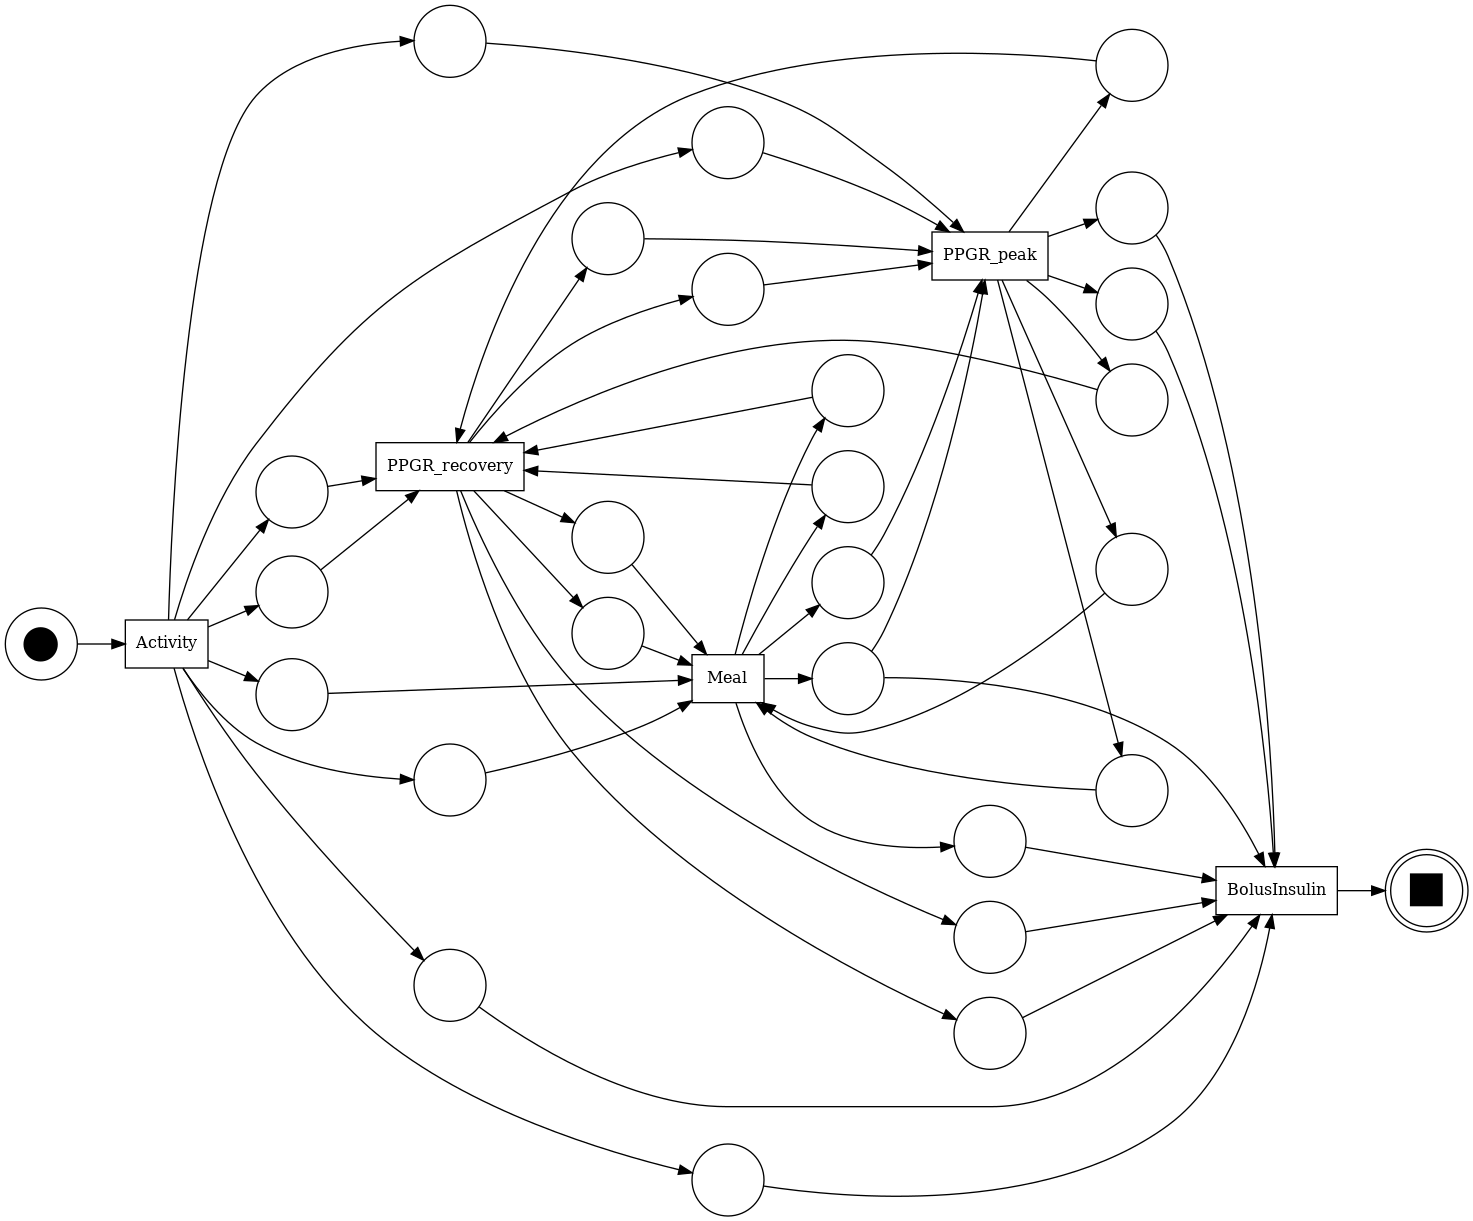

replaying log with TBR, completed traces ::   0%|          | 0/208 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/674 [00:00<?, ?it/s]

'-- Avaliação Fodina --'
{'comprehensibility': 0.03125,
 'fitness': {'average_trace_fitness': 0.41864801235703886,
             'log_fitness': 0.3729399906915115,
             'perc_fit_traces': 0.0,
             'percentage_of_fitting_traces': 0.0},
 'fscore': 0.5432720923274615,
 'generalization': 0.9464084678396782,
 'metricsAverageWeight': 0.6879452227409055,
 'precision': 1.0,
 'recall': 0.37293999069151157,
 'simplicity': 0.43243243243243246}


In [8]:
from pm4py.objects.petri_net.obj import PetriNet, Marking
from pm4py.objects.petri_net.utils import petri_utils
from pm4py.visualization.petri_net import visualizer as pn_visualizer

def pattern_miner_to_petri_net(patterns: PatternMiner):
    tm = patterns.tm

    net = PetriNet("PatternMiner_PN")

    # --- Transitions ---
    transitions = {}
    for t in tm.TC:
        label = tm.tau(t)
        tr = PetriNet.Transition(f"t_{t}", label)
        net.transitions.add(tr)
        transitions[t] = tr

    # --- Places ---
    places = {}

    # Input pattern places (joins)
    for t in tm.TC:
        for i, pattern in enumerate(patterns.IB[t]):
            p = PetriNet.Place(f"p_in_{t}_{i}")
            net.places.add(p)
            places[p.name] = p

            # connect inputs → place
            for src in pattern:
                petri_utils.add_arc_from_to(
                    transitions[src], p, net
                )

            # connect place → task
            petri_utils.add_arc_from_to(
                p, transitions[t], net
            )

    # Output pattern places (splits)
    for t in tm.TC:
        for i, pattern in enumerate(patterns.OB[t]):
            p = PetriNet.Place(f"p_out_{t}_{i}")
            net.places.add(p)
            places[p.name] = p

            # connect task → place
            petri_utils.add_arc_from_to(
                transitions[t], p, net
            )

            # connect place → outputs
            for tgt in pattern:
                petri_utils.add_arc_from_to(
                    p, transitions[tgt], net
                )

    # --- Initial and Final places ---
    im = Marking()
    fm = Marking()

    p_start = PetriNet.Place("p_start")
    p_end = PetriNet.Place("p_end")

    net.places.add(p_start)
    net.places.add(p_end)

    petri_utils.add_arc_from_to(
        p_start, transitions[tm.most_started], net
    )
    petri_utils.add_arc_from_to(
        transitions[tm.most_ended], p_end, net
    )

    im[p_start] = 1
    fm[p_end] = 1

    return net, im, fm

net, im, fm = pattern_miner_to_petri_net(patterns)

gviz = pn_visualizer.apply(net, im, fm)
pn_visualizer.view(gviz)
#pn_visualizer.save(gviz, "caseid_day_HypoHyper/graphs/fodina_petrinet.png")

# transformation to petri net

eval = evaluation.apply(event_log, net, im, fm)
recall = compute_recall(eval)
eval["recall"] = recall
compreh = compute_comprehensibility(net)
eval["comprehensibility"] = compreh


pprint("-- Evaluation Fodina --")
pprint(eval)
